# 03 — Evaluation & Error Analysis

**Kaggle:** Add Input → *140k Real and Fake Faces* **and** Add Input → Your Work → output of the *02b* notebook (it has both final models); Accelerator = GPU; Internet = On.

Theory: [`docs/05_evaluation.md`](../docs/05_evaluation.md)

In [7]:
# --- environment setup: works on Kaggle, Colab and locally ---
import sys, os
REPO = "https://github.com/Mohd2Shaan/Deepfake-Detection-Project.git"
ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules
if ON_KAGGLE or ON_COLAB:
  PROJECT = "/kaggle/working/project" if ON_KAGGLE else "/content/project"
  if os.path.exists(PROJECT):
      !git -C {PROJECT} pull -q
  else:
      !git clone -q {REPO} {PROJECT}
  %cd {PROJECT}
  EXTRA = "" if ON_KAGGLE else "kagglehub"
  !pip install -q grad-cam {EXTRA}
elif os.path.basename(os.getcwd()) == "notebooks":
  os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working dir:", os.getcwd())

/kaggle/working/project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
working dir: /kaggle/working/project


In [8]:
# --- dataset: Kaggle -> attached input is found automatically; Colab/local -> downloaded once (~4 GB) ---
from src import config
if ON_KAGGLE:
    for ckpt in config.import_kaggle_checkpoints():      # notebooks 03/04: models from notebook 02's output
        print("trained model:", ckpt)
if not (config.DATA_DIR / "train").exists():
    if ON_KAGGLE:
        raise RuntimeError("Dataset not found - attach '140k Real and Fake Faces' with Add Input")
    !python scripts/download_dataset.py --move
print("data dir:", config.DATA_DIR)

trained model: /kaggle/working/project/checkpoints/resnet_best.pth
trained model: /kaggle/working/project/checkpoints/efficientnet_best.pth
data dir: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake


In [9]:
from src.evaluate import evaluate
from src import config
table = evaluate(sorted(config.CHECKPOINT_DIR.glob('*_best.pth')))
table


===== efficientnet_b0  (/kaggle/working/project/checkpoints/efficientnet_best.pth) =====


              precision    recall  f1-score   support

        real     0.9988    0.9979    0.9983     10000
        fake     0.9979    0.9988    0.9984     10000

    accuracy                         0.9983     20000
   macro avg     0.9984    0.9984    0.9983     20000
weighted avg     0.9984    0.9983    0.9983     20000

misclassified: 33 / 20000

===== resnet18  (/kaggle/working/project/checkpoints/resnet_best.pth) =====


              precision    recall  f1-score   support

        real     0.9937    0.9857    0.9897     10000
        fake     0.9858    0.9938    0.9898     10000

    accuracy                         0.9898     20000
   macro avg     0.9898    0.9898    0.9897     20000
weighted avg     0.9898    0.9898    0.9897     20000

misclassified: 205 / 20000

===== comparison =====
                 accuracy  precision  recall      f1  roc_auc
model                                                        
efficientnet_b0    0.9984     0.9979  0.9988  0.9984   1.0000
resnet18           0.9898     0.9858  0.9938  0.9898   0.9994


,accuracy,precision,recall,f1,roc_auc
model,,,,,
efficientnet_b0,0.9984,0.9979,0.9988,0.9984,1.0000
resnet18,0.9898,0.9858,0.9938,0.9898,0.9994


## Confusion matrices and ROC curve

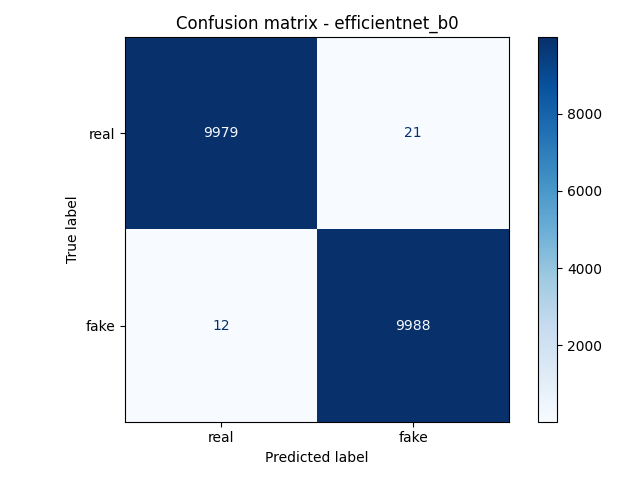

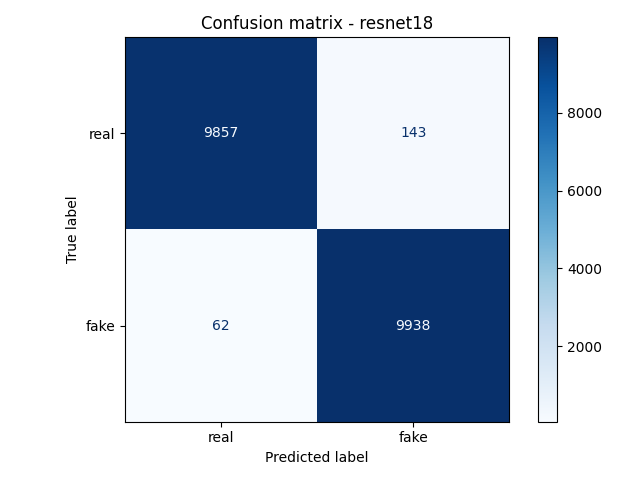

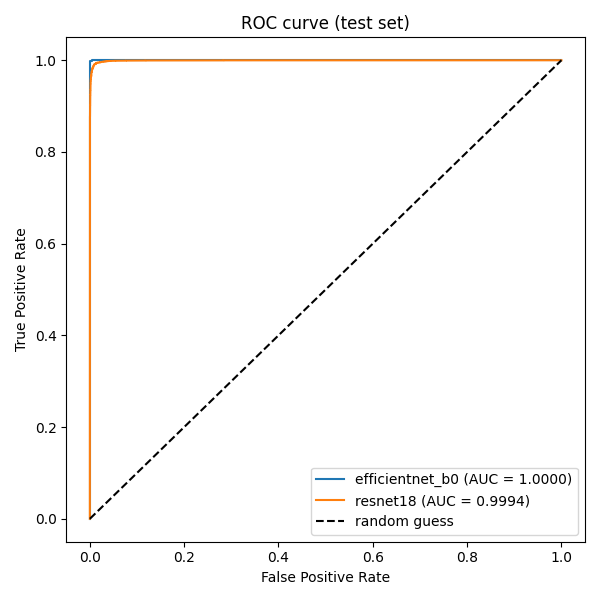

In [10]:
from IPython.display import Image as Show, display
for p in sorted(config.PLOTS_DIR.glob('confusion_matrix_*.png')) + [config.PLOTS_DIR / 'roc_curve.png']:
    display(Show(str(p)))

## Most confident misclassifications

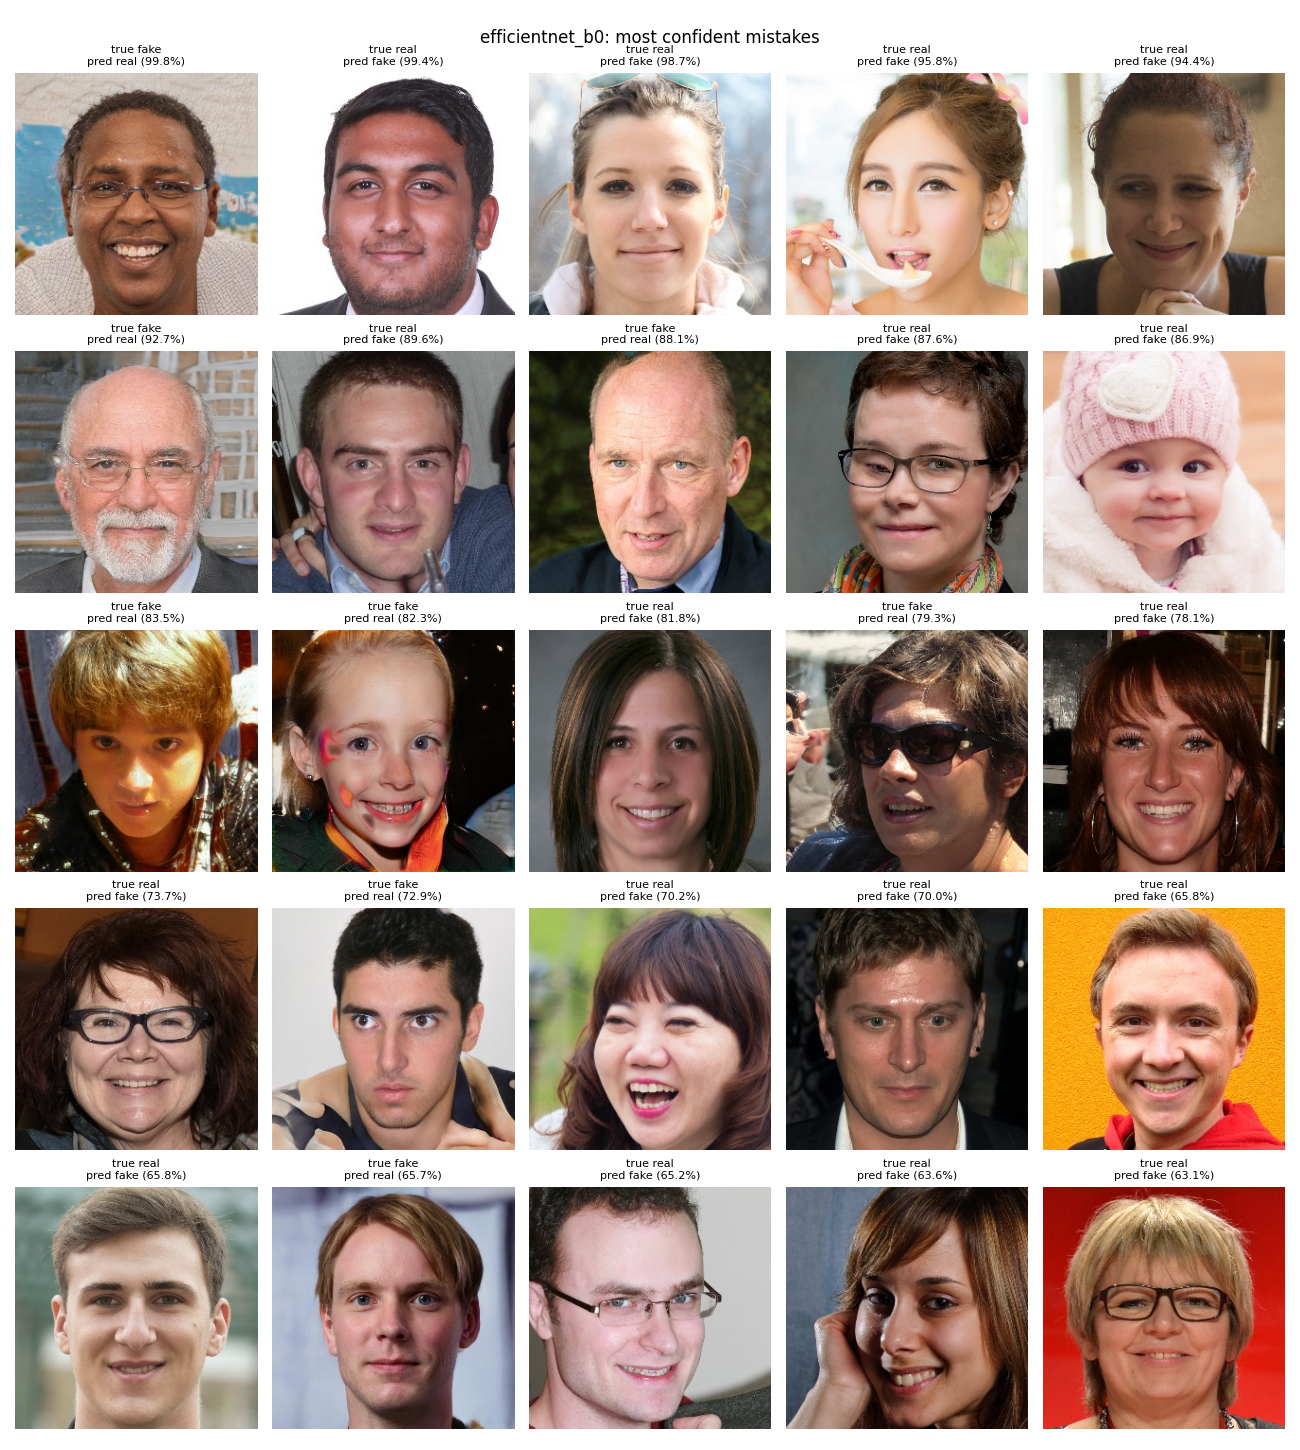

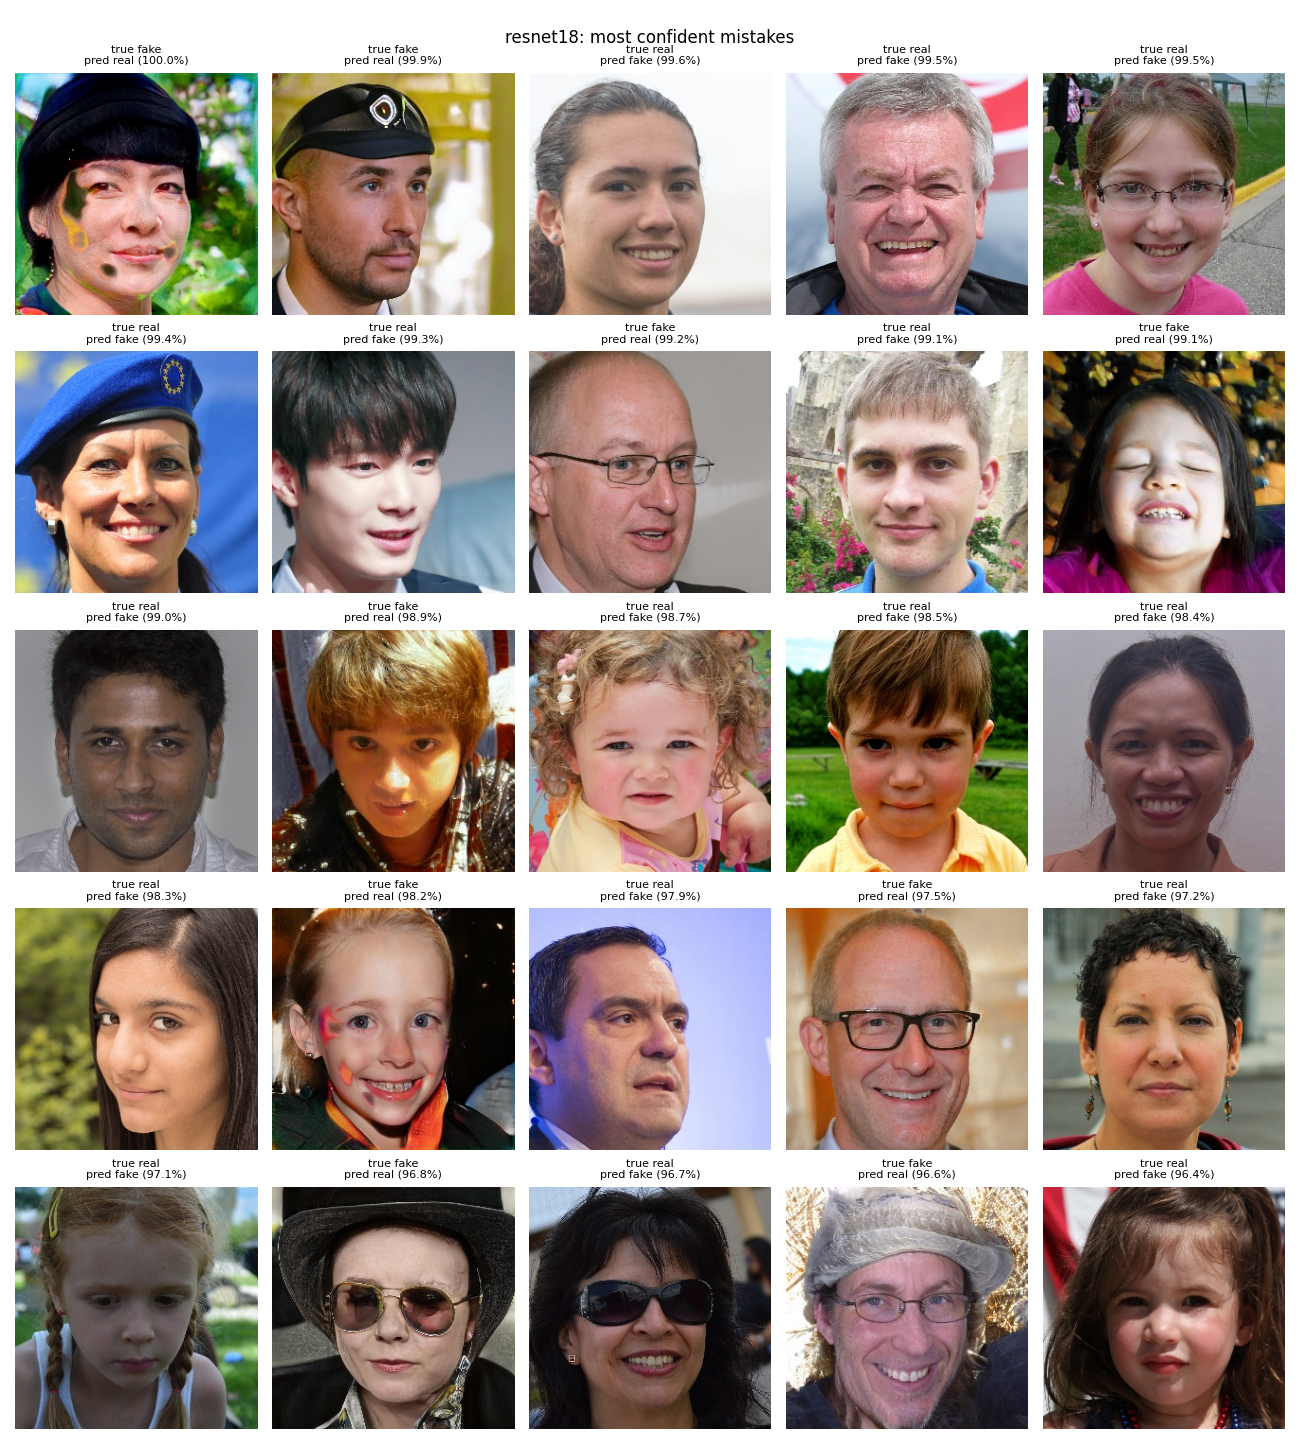

In [11]:
for p in sorted(config.MISCLASSIFIED_DIR.glob('*_most_confident_errors.png')):
    display(Show(str(p)))

In [12]:
import pandas as pd
pd.read_csv(config.MISCLASSIFIED_DIR / 'efficientnet_b0_most_confident_errors.csv').head(10)

,path,true,pred,p_fake,confidence
0,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,1,0,0.001901,0.998099
1,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.993995,0.993995
2,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.986934,0.986934
3,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.957597,0.957597
4,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.943665,0.943665
5,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,1,0,0.072636,0.927364
6,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.895978,0.895978
7,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,1,0,0.119232,0.880768
8,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.876260,0.876260
9,/kaggle/input/datasets/xhlulu/140k-real-and-fa...,0,1,0.868580,0.868580


## Comparison table (test set — 20,000 images never used for training or model selection)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | Errors |
|-------|----------|-----------|--------|----|---------|--------|
| **EfficientNet-B0** (4 blocks fine-tuned) | **99.84%** | 99.79% | 99.88% | **99.84%** | **1.0000** | **33** |
| ResNet-18 | 98.98% | 98.58% | 99.38% | 98.98% | 0.9994 | 205 |

Confusion matrices (rows = true class):

| | EfficientNet-B0 pred real | pred fake | ResNet-18 pred real | pred fake |
|---|---|---|---|---|
| **true real** | 9,979 | 21 | 9,857 | 143 |
| **true fake** | 12 | 9,988 | 62 | 9,938 |

## Observations

1. **Test accuracy matches validation accuracy** (EfficientNet 99.84% test vs 99.88% val; ResNet 98.98% vs 98.96%) →
   the models generalise to unseen images of the same distribution; no over-fitting to the training or validation set.
2. **EfficientNet-B0 makes ~6× fewer mistakes than ResNet-18** (33 vs 205) with ~3× fewer parameters, so it is the
   model used for Grad-CAM and the demo app.
3. **ROC-AUC ≈ 1.000** — almost every fake receives a higher P(fake) than almost every real image; the ranking is
   nearly perfect, so the result does not depend on the 0.5 threshold.
4. **Both models err more on real photos than on fakes** (false positives 21 vs false negatives 12 for EfficientNet,
   143 vs 62 for ResNet): the model is slightly "suspicious".
5. **Typical false positives (real → fake):** studio-like portraits with plain backgrounds, smooth/retouched skin,
   heavy make-up, strong flash or very symmetric frontal faces — i.e. real photos that look as "clean" as StyleGAN output.
6. **Typical false negatives (fake → real):** fakes with busy, realistic backgrounds or clothing, unusual lighting,
   accessories (sunglasses, face paint) — where StyleGAN's usual artifacts are less visible.
7. Most errors are **not** highly confident (65–90%); only a handful exceed 95%.
